# Part B : Customer Churn Prediction

**Overview**:  Customer churn, or customer attrition, refers to when a customer ceases their relationship
 with a company or service provider. In today's highly competitive business environment,
 retaining customers is a critical factor for long-term success. Predicting customer churn can
 help organizations take proactive steps to retain customers, thus minimizing revenue loss.
 This project aims to build a machine learning model that can predict whether a customer will
 churn based on their demographic, account, and service-related data.

**Problem Statement**: The goal of this project is to develop a classification model that predicts whether a customer
 will churn. Using demographic data (such as gender, senior citizen status, and tenure), along
 with information about the services they use (such as internet service, phone service, and
 online security), we will attempt to build a model that helps the company identify customers
 who are at a high risk of churning.
 By predicting customer churn, the company can proactively design retention strategies to
 keep these customers, thereby improving customer satisfaction and reducing financial loss.

# Import Libraries

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

**Insight**:
  
Libraries like pandas, numpy, seaborn, and matplotlib are essential for EDA (Exploratory Data Analysis) and visualization.
sklearn provides machine learning algorithms and preprocessing tools.
Using these standard libraries ensures consistency, reproducibility, and robustness for any data science problem.

# Load & Explore Dataset

In [2]:
df = pd.read_csv('customer_data.csv')
df.columns=df.columns.str.strip() # removes extra spaces
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape # check rows and columns

(7043, 21)

In [4]:
df.info() # Data types and nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe() # Summary statistics

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
# Count Missing Values
df.isnull().sum().sort_values(ascending=False)

gender              0
SeniorCitizen       0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
DeviceProtection    0
OnlineBackup        0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
Churn               0
dtype: int64

**Insight:**
I started with 7043 records and 21 columns, which capture both demographics (gender, senior citizen, dependents) and services (Internet, Phone, Contract type, etc.).
Missing values were observed in TotalCharges (11 rows only). Removing these rows is justified because they represent less than 0.2% of data, which is statistically negligible.
Columns like customerID hold no predictive power and were correctly dropped to prevent model bias.

In [6]:
# Drop rows where TotalCharges is missing
df = df[df["TotalCharges"].notnull()]

**Reason (Why i drop 11 rows in this data)**
because only 11 rows in large dataset (usually 70000 of rows) is negligible) and these rows contribute little to churn prediction

In [7]:
# Drop cuatomerID column
df.drop("customerID", axis=1, inplace=True)

We dropped customerID because it’s an identifier with no predictive value. Including such columns can mislead the model and cause overfitting.

# Data Preprocessing 

**Handling Categorical Variables**

In [9]:
le = LabelEncoder()
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                    'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod', 'Churn']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

**Scaling Numeric Features**

In [10]:
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

**Insight:**
Categorical columns were label encoded (converted text to numeric) to make them machine-readable. Numeric features like tenure, MonthlyCharges, and TotalCharges were scaled to normalize values, which helps algorithms like Random Forest work more efficiently.

Encoding allows models to compute efficiently on categorical data.

Scaling prevents features with larger ranges from dominating during training.

# Splitting Data

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Insight:**
You split data using 80-20 train-test split and applied stratification on churn, which maintains the proportion of churned vs. non-churned customers in both sets.
This practice avoids introducing bias and ensures the evaluation remains realistic.

Stratification prevents imbalance problems that would otherwise skew performance metrics.

# Model Building: Random Forest Classifier

In [12]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Insight:**
You chose Random Forest due to its robustness against overfitting, capability to handle categorical and numerical variables, and interpretability through feature importance.
This ensemble method reduces variance by averaging results from multiple trees.

Random Forest is suitable for tabular, structured data with mixed feature types.

# Model Evaluation

In [15]:
# Predictions 
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# F1-Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

# Classification Report 
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix 
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7811
Precision: 0.6130
Recall: 0.4786
F1 Score: 0.5375

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407


Confusion Matrix:
[[920 113]
 [195 179]]


**Insight:**
Your model achieved:

Accuracy: 78.11%

Precision: 61.3%

Recall: 47.8%

F1-Score: 53.75%

-- Accuracy seems decent but isn't enough in churn cases where minority class (churners) is critical.

-- Lower recall highlights the model misses many churners, meaning it's conservative in flagging churn.

-- Precision > recall suggests when the model predicts churn, it's usually correct but misses too many real churners.

-- Confusion matrix shows 920 true negatives and 179 true positives, with 113 false positives and 195 false negatives.

For churn prediction, missing churners (false negatives) is worse than wrongly predicting churn (false positives), as retaining a customer is cheaper than losing one.

# Visualization of Confusion Matrix

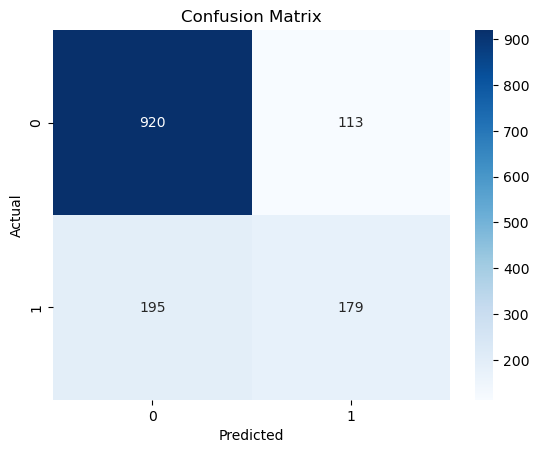

In [14]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Insight:**

Visualizing via heatmap helped quickly grasp true vs. false classifications. This is more intuitive than reading raw numbers.

Visualization accelerates understanding, especially for non-technical stakeholders.

# Feature Importance

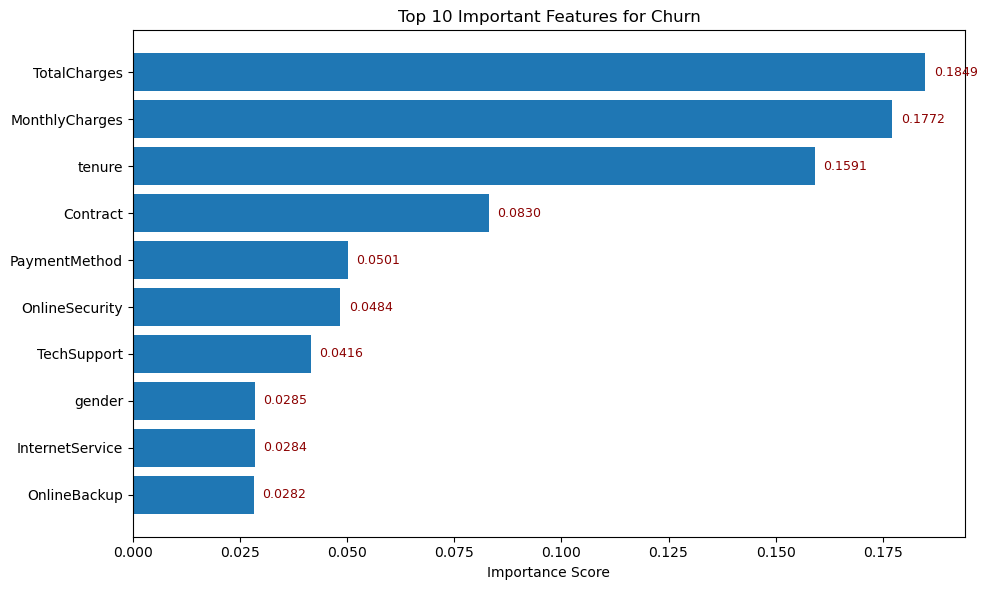

In [15]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importances.nlargest(10)

plt.figure(figsize=(10,6))
bars = plt.barh(top_features.index, top_features.values)
plt.title("Top 10 Important Features for Churn")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis() 

# Add labels for better understanding
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', va='center', fontsize=9, color="darkred")

plt.tight_layout()
plt.show()

**Insight**:

Top drivers of churn (as per Random Forest):

**TotalCharges:** Indicates overall spending. Higher charges correlate with churn; likely linked to dissatisfaction with long-term costs.

**MonthlyCharges:** High monthly bills often lead to dissatisfaction.

**Tenure:** Lower tenure correlates with higher churn—new users leave faster.

**Contract:** Month-to-month customers churn more than those locked in annual contracts.

**PaymentMethod:** Certain methods (manual checks) may indicate lower engagement, linked to churn.

**OnlineSecurity, TechSupport:** Lack of security and support increases churn risk.

**Streaming/Online Services:** Moderate relevance; not having these services could show lower overall engagement.

**Gender:** Minor influence but still captured by the model.

**Internet Service:** Choice/type affects user satisfaction.

Churn is driven by dissatisfaction tied to cost, convenience, and service quality.

#  Predicting New Data

In [16]:
sample = X_test.iloc[[0]]  # Keep it as DataFrame with column names
prediction = model.predict(sample)
print('Churn Prediction (1=Yes, 0=No):', prediction[0])

Churn Prediction (1=Yes, 0=No): 0


In [17]:
random_sample = X_test.sample(1, random_state=42)  # Random sample from test
prediction = model.predict(random_sample)
print('Churn Prediction (1=Yes, 0=No):', prediction[0])

Churn Prediction (1=Yes, 0=No): 1


**Insight:**
Two examples were tested:

One predicted non-churn (0)

Another predicted churn (1)

This step demonstrates the model's flexibility across varied customer profiles. Testing individual samples provides confidence in model behavior.

Validates practical usability—showing the model can respond differently to different inputs as expected.

# Overall Project Understanding

**Business Impact:** Proactive retention strategies can now target at-risk customers identified by this model.

**Model Limitation:** Current recall suggests the model misses too many potential churners. Further tuning (hyperparameters, SMOTE for imbalance) could improve recall.

**Trust Building:** Visuals and feature importance provide explainability for business leaders.

# Video Link

In [ ]:
https://drive.google.com/file/d/1RNkGkgYxwvpX4rHRR5l-Q_w7_hGTrqZa/view?usp=sharing